# Study: Bag of Visual Words (BoVW) with CNN Descriptors + SVM

This notebook demonstrates the Bag of Visual Words approach using CNN convolutional layer descriptors.

## Methodology
- **Feature Extraction**: Extract local descriptors from CNN convolutional layers (spatial features)
- **Vocabulary Building**: K-Means clustering to build visual vocabulary
- **Histogram Encoding**: Create BoVW histograms for each image
- **Classifier**: Support Vector Machine (SVM) with RBF kernel
- **Dataset**: UCMerced Land Use Dataset (21 classes)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
import time

from data import DataLoader
from config import ExperimentConfig
from features import FeatureExtractor
from vocabulary import VocabularyBuilder
from classifier import Classifier

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-30 13:30:17.682587: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Load Data and Configuration


In [2]:
# Configuration for BoVW with CNN descriptors
config = ExperimentConfig(
    data_dir="UCMerced_LandUse",
    classifier_type="svm",
    svm_kernel="rbf",
    svm_C=1.0,
    dsc_method="cnn",  # Use CNN for descriptor extraction
    cnn_model="vgg16",  # Options: vgg16, resnet18, resnet50
    vocab_size=150,  # Number of visual words
    use_minibatch_kmeans=True,
    normalize_histograms=True
)

# Load data
print("Loading images...")
data_loader = DataLoader(config)
images, labels, class_names = data_loader.load_images_and_labels()

print(f"\nDataset Statistics:")
print(f"  Total images: {len(images)}")
print(f"  Number of classes: {len(class_names)}")
print(f"  Classes: {class_names}")


Loading images...
Loading images from: UCMerced_LandUse
Found classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Loaded 2100 images from 21 classes

Dataset Statistics:
  Total images: 2100
  Number of classes: 21
  Classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']


## 2. Extract CNN Local Descriptors


In [3]:
# Extract local descriptors from CNN convolutional layers
print(f"Extracting CNN local descriptors using {config.cnn_model.upper()}...")
print("Note: Extracting spatial features from convolutional layers (not FC layer)\n")

feature_extractor = FeatureExtractor(config)
start_time = time.time()
image_descriptors, all_descriptors = feature_extractor.extract_descriptors(images)
extraction_time = time.time() - start_time

print(f"\nDescriptor Extraction Complete!")
print(f"  Total descriptors: {all_descriptors.shape[0]}")
print(f"  Descriptor dimension: {all_descriptors.shape[1]}")
print(f"  Number of images: {len(image_descriptors)}")
print(f"  Extraction time: {extraction_time:.2f} seconds")


Extracting CNN local descriptors using VGG16...
Note: Extracting spatial features from convolutional layers (not FC layer)

Descriptor method: CNN


/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ayoub/miniconda3/envs/develop/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Processed 800/2100 images -> feature map 14x14, channels=512
  Processed 1600/2100 images -> feature map 14x14, channels=512
  Processed 2100/2100 images -> feature map 14x14, channels=512
Total CNN local descriptors (stacked): (411600, 512)

Descriptor Extraction Complete!
  Total descriptors: 411600
  Descriptor dimension: 512
  Number of images: 2100
  Extraction time: 13.26 seconds


## 3. Build Visual Vocabulary


In [4]:
# Build vocabulary using K-Means clustering
print(f"Building visual vocabulary with {config.vocab_size} visual words...")

vocab_builder = VocabularyBuilder(config)
start_time = time.time()
vocabulary = vocab_builder.build_vocabulary(all_descriptors)
vocab_time = time.time() - start_time

print(f"\nVocabulary built!")
print(f"  Vocabulary shape: {vocabulary.shape}")
print(f"  Vocabulary building time: {vocab_time:.2f} seconds")


Building visual vocabulary with 150 visual words...
Building vocabulary with 150 visual words...
Vocabulary built. Shape: (150, 512)

Vocabulary built!
  Vocabulary shape: (150, 512)
  Vocabulary building time: 2.10 seconds


## 4. Compute BoVW Histograms


In [5]:
# Compute histograms for each image
print("Computing BoVW histograms...")

start_time = time.time()
histograms = vocab_builder.compute_histograms(image_descriptors)
histogram_time = time.time() - start_time

print(f"\nHistograms computed!")
print(f"  Histograms shape: {histograms.shape}")
print(f"  Histogram computation time: {histogram_time:.2f} seconds")


Computing BoVW histograms...
Computing BoVW histograms for 2100 images...
  Processed 500/2100 histograms
  Processed 1000/2100 histograms
  Processed 1500/2100 histograms
  Processed 2000/2100 histograms
Histograms computed. Shape: (2100, 150)

Histograms computed!
  Histograms shape: (2100, 150)
  Histogram computation time: 1.39 seconds


## 5. Train/Test Split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    histograms, labels, 
    test_size=0.2, 
    random_state=42,
    stratify=labels
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimension (vocab size): {X_train.shape[1]}")


Training set: 1680 samples
Test set: 420 samples
Feature dimension (vocab size): 150


## 6. Train SVM Classifier


In [7]:
print(f"Training SVM with {config.svm_kernel.upper()} kernel...")
print(f"  C: {config.svm_C}")

clf = Classifier(config)
train_start = time.time()
clf.train(X_train, y_train)
train_time = time.time() - train_start

print(f"\nTraining complete! Time: {train_time:.2f} seconds")


Training SVM with RBF kernel...
  C: 1.0
Created SVM classifier (kernel=rbf, C=1.0, gamma=scale)
Training SVM classifier...
  Training samples: 1680
  Feature dimension: 150
Training complete!

Training complete! Time: 0.15 seconds


## 7. Evaluate Model


In [8]:
# Evaluate model
metrics_dict = clf.evaluate(X_test, y_test, class_names)

accuracy = metrics_dict['accuracy']
precision = metrics_dict['precision']
recall = metrics_dict['recall']
f1 = metrics_dict['f1_score']

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*60)


MODEL PERFORMANCE METRICS
Accuracy:  0.8905 (89.05%)
Precision: 0.8976
Recall:    0.8905
F1-Score:  0.8899


## 8. Visualizations

### 8.1 Confusion Matrix


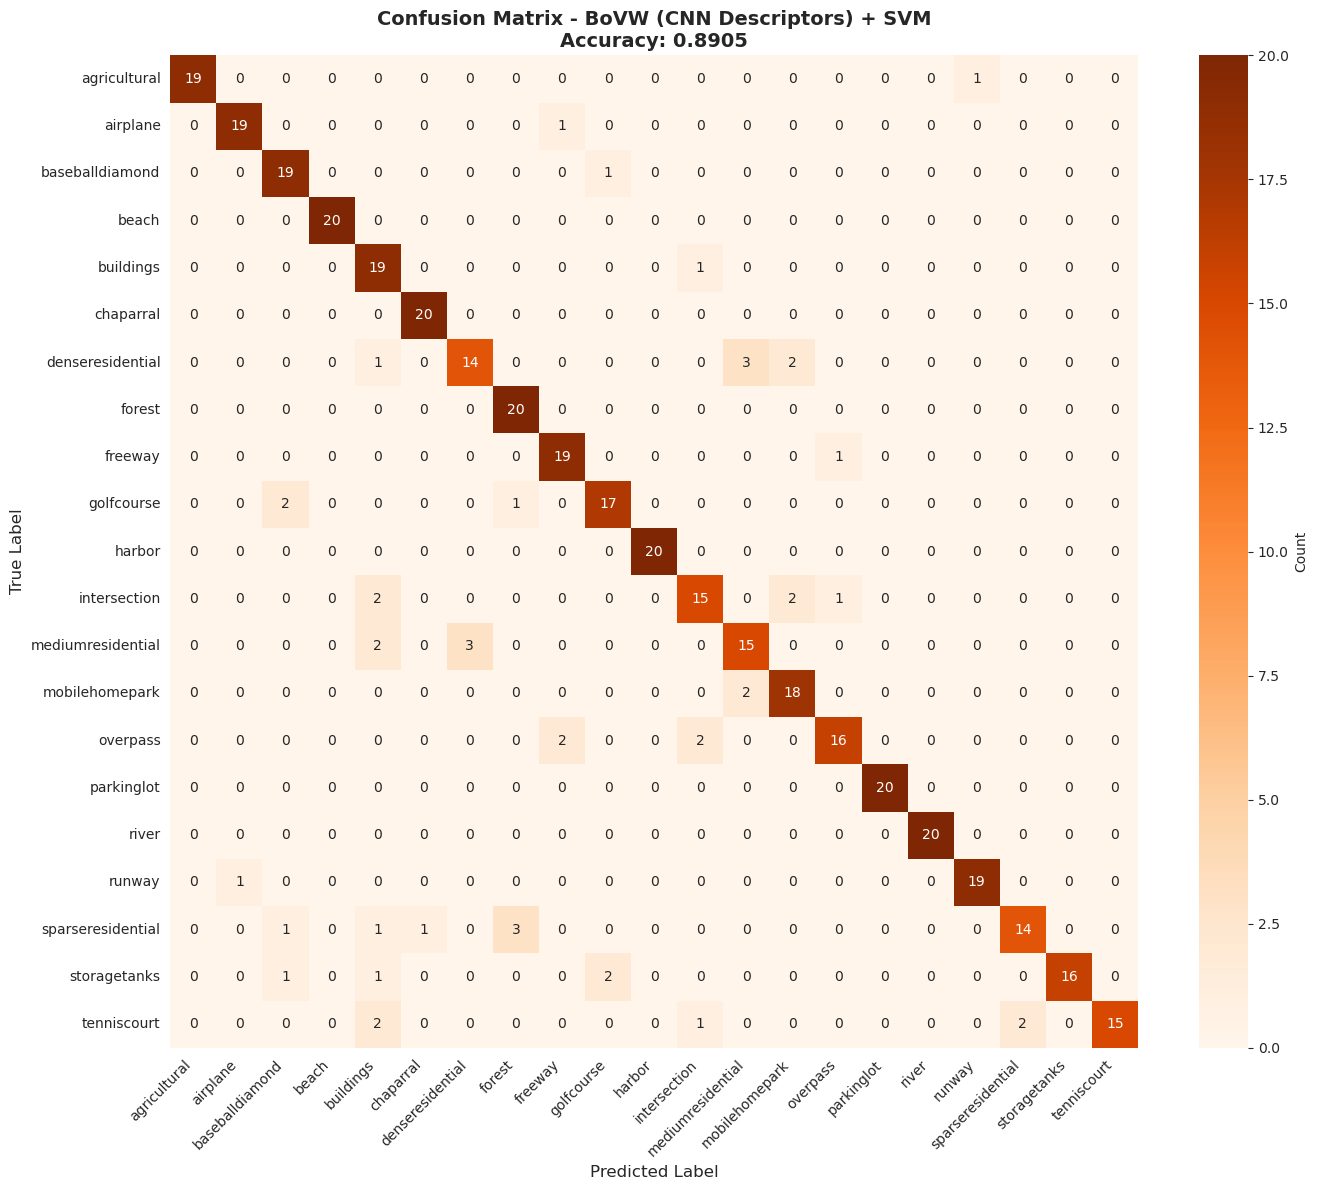

In [9]:
conf_matrix = metrics_dict['confusion_matrix']

plt.figure(figsize=(14, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - BoVW (CNN Descriptors) + SVM\nAccuracy: {accuracy:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 8.2 Per-Class Performance Metrics


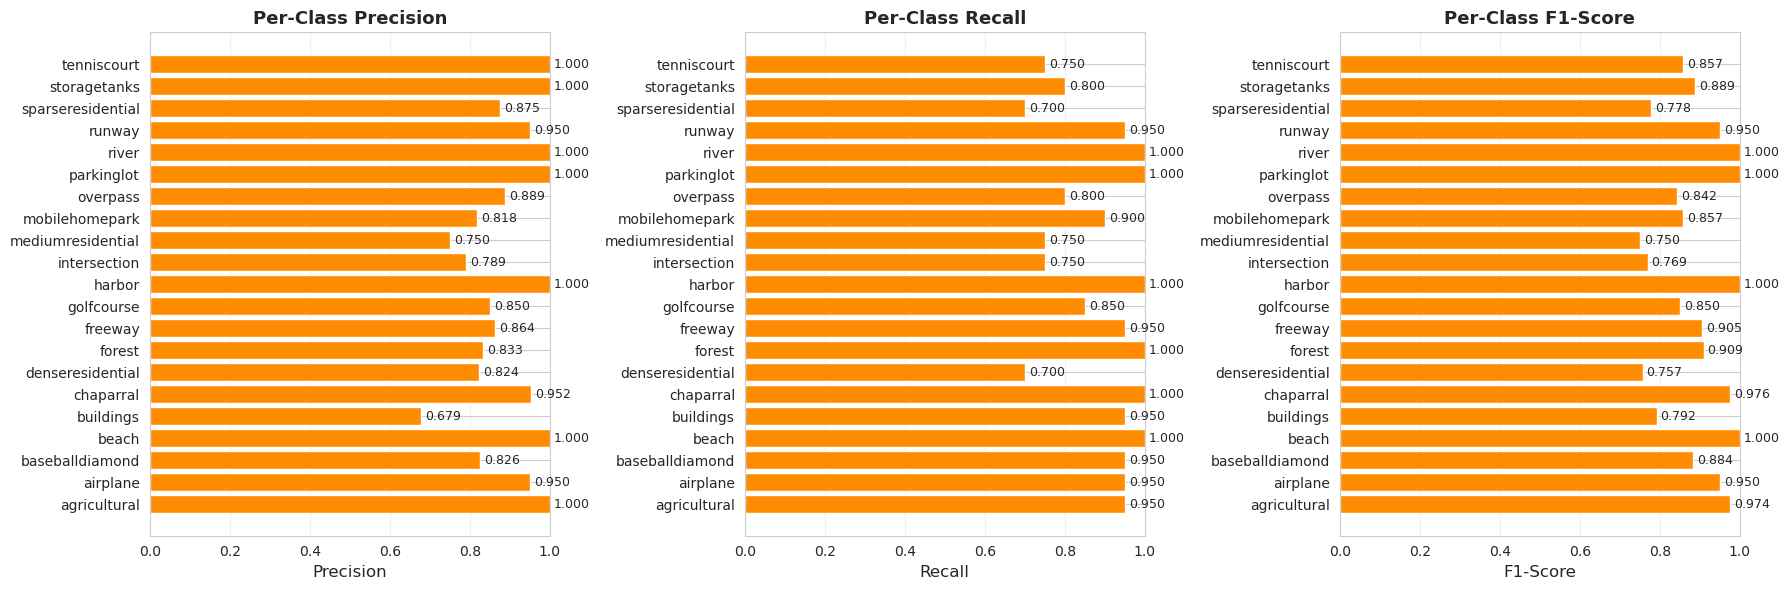


Per-Class Performance Metrics:
            Class  Precision  Recall  F1-Score  Support
     agricultural   1.000000    0.95  0.974359     20.0
         airplane   0.950000    0.95  0.950000     20.0
  baseballdiamond   0.826087    0.95  0.883721     20.0
            beach   1.000000    1.00  1.000000     20.0
        buildings   0.678571    0.95  0.791667     20.0
        chaparral   0.952381    1.00  0.975610     20.0
 denseresidential   0.823529    0.70  0.756757     20.0
           forest   0.833333    1.00  0.909091     20.0
          freeway   0.863636    0.95  0.904762     20.0
       golfcourse   0.850000    0.85  0.850000     20.0
           harbor   1.000000    1.00  1.000000     20.0
     intersection   0.789474    0.75  0.769231     20.0
mediumresidential   0.750000    0.75  0.750000     20.0
   mobilehomepark   0.818182    0.90  0.857143     20.0
         overpass   0.888889    0.80  0.842105     20.0
       parkinglot   1.000000    1.00  1.000000     20.0
            rive

In [10]:
# Get per-class metrics
report = metrics_dict['classification_report']

# Extract metrics for each class
class_metrics = []
for class_name in class_names:
    if class_name in report:
        class_metrics.append({
            'Class': class_name,
            'Precision': report[class_name]['precision'],
            'Recall': report[class_name]['recall'],
            'F1-Score': report[class_name]['f1-score'],
            'Support': report[class_name]['support']
        })

metrics_df = pd.DataFrame(class_metrics)

# Plot per-class metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.barh(range(len(metrics_df)), metrics_df[metric], color='darkorange')
    ax.set_yticks(range(len(metrics_df)))
    ax.set_yticklabels(metrics_df['Class'])
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Per-Class {metric}', fontsize=13, fontweight='bold')
    ax.set_xlim([0, 1])
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, metrics_df[metric])):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Display metrics table
print("\nPer-Class Performance Metrics:")
print(metrics_df.to_string(index=False))


### 8.3 Overall Metrics Summary


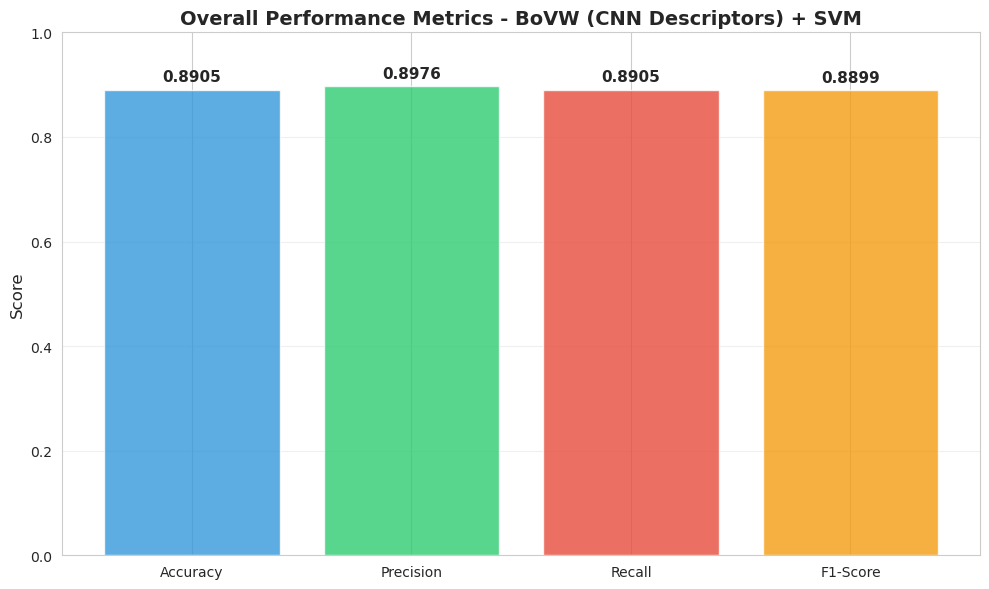

In [11]:
# Create summary bar plot
metrics_summary = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics_summary.keys(), metrics_summary.values(), 
               color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Overall Performance Metrics - BoVW (CNN Descriptors) + SVM', 
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, (metric, value) in zip(bars, metrics_summary.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 9. Summary


In [12]:
print("="*60)
print("STUDY SUMMARY")
print("="*60)
print(f"Feature Extraction Method: CNN Local Descriptors ({config.cnn_model.upper()})")
print(f"  - Extracting spatial features from convolutional layers")
print(f"  - Total descriptors extracted: {all_descriptors.shape[0]}")
print(f"  - Descriptor dimension: {all_descriptors.shape[1]}")
print(f"  - Extraction time: {extraction_time:.2f} seconds")
print(f"\nBoVW Pipeline:")
print(f"  - Vocabulary size: {config.vocab_size}")
print(f"  - Vocabulary building time: {vocab_time:.2f} seconds")
print(f"  - Histogram computation time: {histogram_time:.2f} seconds")
print(f"\nClassifier: SVM")
print(f"  - Kernel: {config.svm_kernel.upper()}")
print(f"  - C: {config.svm_C}")
print(f"  - Training time: {train_time:.2f} seconds")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print("="*60)


STUDY SUMMARY
Feature Extraction Method: CNN Local Descriptors (VGG16)
  - Extracting spatial features from convolutional layers
  - Total descriptors extracted: 411600
  - Descriptor dimension: 512
  - Extraction time: 13.26 seconds

BoVW Pipeline:
  - Vocabulary size: 150
  - Vocabulary building time: 2.10 seconds
  - Histogram computation time: 1.39 seconds

Classifier: SVM
  - Kernel: RBF
  - C: 1.0
  - Training time: 0.15 seconds

Performance:
  - Accuracy:  0.8905 (89.05%)
  - Precision: 0.8976
  - Recall:    0.8905
  - F1-Score:  0.8899
